In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model

In [4]:
def load_img(path):
    img = image.load_img(path, target_size=(224,224))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    return img

content_path = "content.jpg"
style_path = "style.jpg"

content_image = load_img(content_path)
style_image = load_img(style_path)

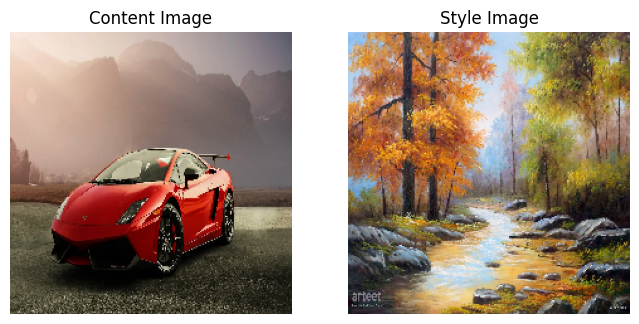

In [5]:
def show_img(img, title=None):
    img = img.reshape((224,224,3))
    img[:,:,0] += 103.939
    img[:,:,1] += 116.779
    img[:,:,2] += 123.68
    img = img[:,:,::-1]
    img = np.clip(img,0,255).astype('uint8')

    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
show_img(content_image, "Content Image")

plt.subplot(1,2,2)
show_img(style_image, "Style Image")

In [6]:
vgg = VGG19(weights='imagenet', include_top=False)

for layer in vgg.layers:
    layer.trainable = False

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
content_layers = ['block5_conv2']

style_layers = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

In [8]:
outputs = [vgg.get_layer(name).output for name in style_layers + content_layers]

model = Model(inputs=vgg.input, outputs=outputs)

In [9]:
def gram_matrix(tensor):
    result = tf.linalg.einsum('bijc,bijd->bcd', tensor, tensor)
    shape = tf.shape(tensor)
    num_locations = tf.cast(shape[1]*shape[2], tf.float32)
    return result / num_locations

In [10]:
def content_loss(base, target):
    return tf.reduce_mean(tf.square(base - target))

In [11]:
def style_loss(base, target):
    gram_base = gram_matrix(base)
    gram_target = gram_matrix(target)
    return tf.reduce_mean(tf.square(gram_base - gram_target))

In [12]:
style_targets = model(style_image)[:len(style_layers)]
content_targets = model(content_image)[len(style_layers):]

In [13]:
content_weight = 1e4
style_weight = 1e-2

def total_loss(outputs):

    style_outputs = outputs[:len(style_layers)]
    content_outputs = outputs[len(style_layers):]

    s_loss = 0
    for s_out, s_target in zip(style_outputs, style_targets):
        s_loss += style_loss(s_out, s_target)

    c_loss = 0
    for c_out, c_target in zip(content_outputs, content_targets):
        c_loss += content_loss(c_out, c_target)

    total = style_weight*s_loss + content_weight*c_loss
    return total

In [14]:
generated_image = tf.Variable(content_image, dtype=tf.float32)

In [15]:
optimizer = tf.optimizers.Adam(learning_rate=0.02)

epochs = 300

for i in range(epochs):

    with tf.GradientTape() as tape:
        outputs = model(generated_image)
        loss = total_loss(outputs)

    grads = tape.gradient(loss, generated_image)
    optimizer.apply_gradients([(grads, generated_image)])

    if i % 50 == 0:
        print("Iteration:", i, "Loss:", loss.numpy())

Iteration: 0 Loss: 2804888600.0
Iteration: 50 Loss: 2287568100.0
Iteration: 100 Loss: 1888561800.0
Iteration: 150 Loss: 1545271800.0
Iteration: 200 Loss: 1259570200.0
Iteration: 250 Loss: 1031605440.0


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

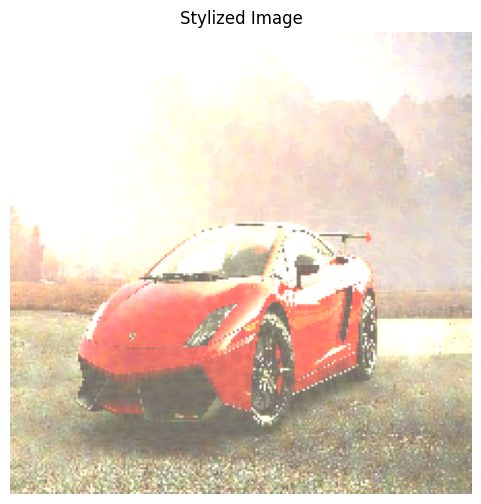

In [16]:
def deprocess(img):
    img = img.reshape((224,224,3))
    img[:,:,0] += 103.939
    img[:,:,1] += 116.779
    img[:,:,2] += 123.68
    img = img[:,:,::-1]
    img = np.clip(img,0,255).astype('uint8')
    return img

result = deprocess(generated_image.numpy())

plt.figure(figsize=(6,6))
plt.imshow(result)
plt.title("Stylized Image")
plt.axis('off')